# NVIDIA — Descriptive Analysis

*What happened.* This notebook tells the visual story of NVIDIA's market performance and earnings from 2010 to 2026, alongside the three AI-era bands. Formal break detection and hypothesis tests live in the **diagnostic** notebook; here we describe NVIDIA's own trajectory, its divergence from peers, and the hyperscaler-capex backdrop.

> **Non-causal framing.** Every chart documents *temporal alignment* — where a shift in NVIDIA's series lines up with an AI milestone — not causation. Findings should describe association only.

**Eras:** Pre-Attention / CNN (2010Q1–2017Q2) · Transformer (2017Q3–2022Q3) · Generative-AI (2022Q4–2026Q1). AlexNet (2012Q3) is marked *inside* the first band.

## Setup

In [15]:
import sys
from pathlib import Path

# Walk up to the repo root and put Source/ on the path, so `import common`
# works whether Jupyter is launched from the repo root or this folder.
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "Source" / "common.py").exists():
        sys.path.insert(0, str(_p / "Source")); break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import common
import importlib
importlib.reload(common)   # pick up edits to common.py without restarting the kernel
common.apply_style()

panel = common.load_panel()
seg   = common.load_segments()
daily = common.load_daily()

# Save every figure into ./figures next to this notebook.
FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)
def save(fig, name): fig.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")

print(f"panel : {panel.shape[0]} rows | {panel['ticker'].nunique()} tickers | "
      f"{panel['calendar_quarter'].min()}-{panel['calendar_quarter'].max()}")
print(f"seg   : {seg.shape[0]} fiscal years | FY{seg['fiscal_year'].min()}-FY{seg['fiscal_year'].max()}")
print(f"daily : {daily.shape[0]} rows | {daily['ticker'].nunique()} tickers")

panel : 577 rows | 9 tickers | 2010Q1-2026Q1
seg   : 13 fiscal years | FY2013-FY2025
daily : 20425 rows | 5 tickers


## Data sanity check
Confirm coverage before plotting — date ranges, per-ticker counts, and how NVIDIA's quarters distribute across the three eras.

In [16]:
cov = (panel.groupby("ticker")
       .agg(rows=("calendar_quarter", "size"),
            first=("calendar_quarter", "min"),
            last=("calendar_quarter", "max"),
            price=("qend_adj_close", lambda s: int(s.notna().sum())),
            revenue=("revenue", lambda s: int(s.notna().sum())),
            capex=("capex", lambda s: int(s.notna().sum()))))
print(cov.to_string())
print("\nNVDA quarters per era:")
print(panel[panel.ticker == "NVDA"]["era"]
      .value_counts().reindex([e.name for e in common.ERAS]).to_string())

        rows   first    last  price  revenue  capex
ticker                                             
AMD       65  2010Q1  2026Q1     65       64      0
AMZN      64  2010Q1  2025Q4      0        0     64
GOOGL     64  2010Q1  2025Q4      0        0     64
INTC      65  2010Q1  2026Q1     65       64      0
META      60  2010Q3  2025Q4      0        0     60
MSFT      64  2010Q1  2025Q4      0        0     64
NDX       65  2010Q1  2026Q1     65        0      0
NVDA      65  2010Q1  2026Q1     65       64      0
SOX       65  2010Q1  2026Q1     65        0      0

NVDA quarters per era:
era
Pre-Attention / CNN    30
Transformer            21
Generative-AI          14


## 1. NVIDIA's own story

NVIDIA on its own terms — price, earnings, segment mix, and margin structure — before any peer comparison. Price and the revenue/income series are on a **linear (raw)** scale, so the Generative-AI surge shows at true magnitude. The segment and margin charts are **annual** (NVIDIA discloses segments only once a year in the 10-K).

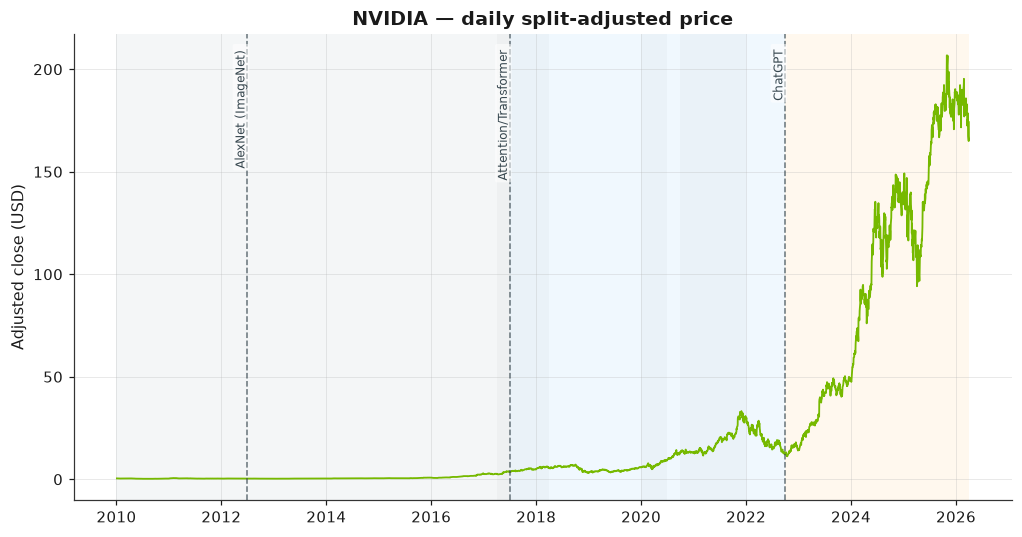

In [17]:
fig, ax = plt.subplots()
nv = daily[daily.ticker == "NVDA"].sort_values("date")
ax.plot(nv["date"], nv["adj_close"], color=common.color("NVDA"), lw=1.2)
common.annotate(ax)
common.style_time_axis(ax)
ax.set_ylabel("Adjusted close (USD)")
ax.set_title("NVIDIA — daily split-adjusted price")
save(fig, "01_nvda_price"); plt.show()

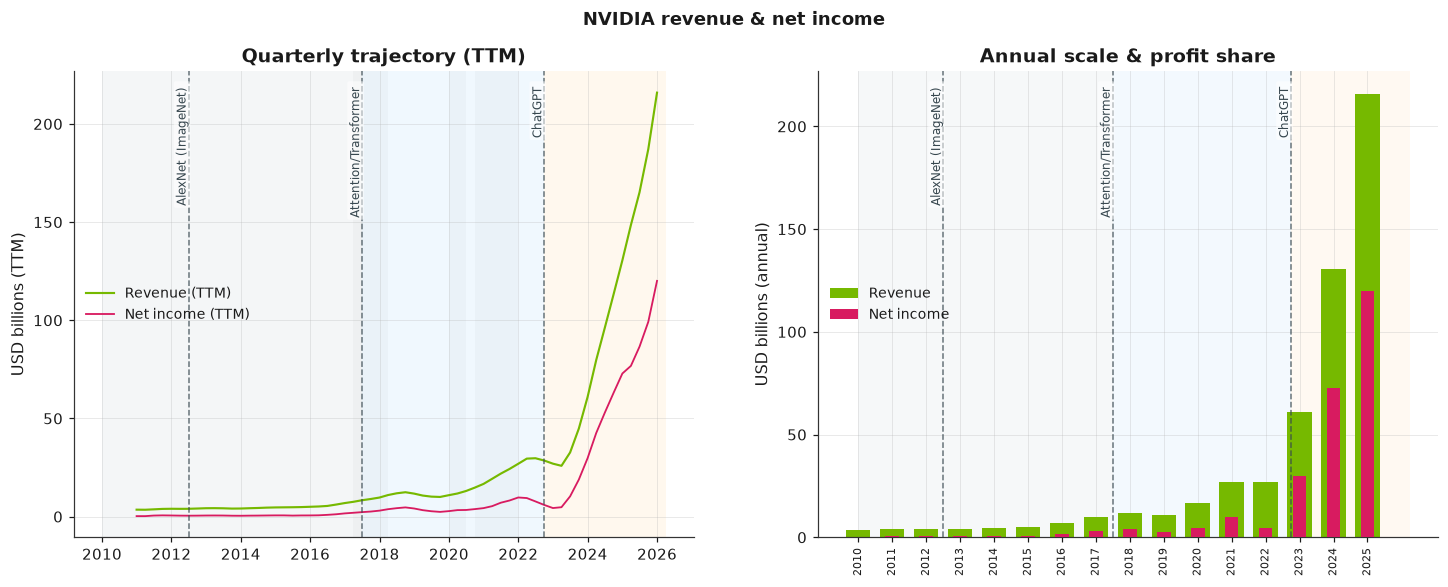

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# LEFT — current: TTM lines
r = common.ticker_series(panel, "NVDA", "revenue_ttm")
n = common.ticker_series(panel, "NVDA", "netincome_ttm")
ax1.plot(r["date"], r["revenue_ttm"]/1e9, color=common.color("NVDA"), lw=1.4, label="Revenue (TTM)")
ax1.plot(n["date"], n["netincome_ttm"]/1e9, color="#d81b60", lw=1.2, label="Net income (TTM)")
common.annotate(ax1); common.style_time_axis(ax1)
ax1.set_ylabel("USD billions (TTM)")
ax1.set_title("Quarterly trajectory (TTM)")
ax1.legend(loc="center left")

# RIGHT — alternative: nested annual bars
nvq = panel[panel.ticker == "NVDA"].copy()
nvq["year"] = nvq["calendar_quarter"].str[:4].astype(int)
nvq = nvq.dropna(subset=["revenue", "net_income"])
cnt = nvq.groupby("year")["revenue"].size()
yy = cnt[cnt == 4].index
gg = nvq[nvq.year.isin(yy)].groupby("year")[["revenue", "net_income"]].sum()/1e9
yrs = gg.index.values
common.add_era_bands_year(ax2); common.add_milestones_year(ax2, label=True)
ax2.bar(yrs, gg["revenue"], width=0.72, color=common.color("NVDA"), label="Revenue", zorder=2)
ax2.bar(yrs, gg["net_income"], width=0.40, color="#d81b60", label="Net income", zorder=3)
ax2.set_xticks(yrs); ax2.set_xticklabels([str(y) for y in yrs], rotation=90, fontsize=7)
ax2.set_ylabel("USD billions (annual)")
ax2.set_title("Annual scale & profit share")
ax2.legend(loc="center left")

fig.suptitle("NVIDIA revenue & net income", fontweight="bold")
save(fig, "02_revenue_compare"); plt.show()

Segment mix (annual). Watch **Data Center** overtake **Gaming** and then dominate through the Gen-AI band — this single chart subsumes the old standalone share-line, which showed the same crossover. Year ticks align under each bar.

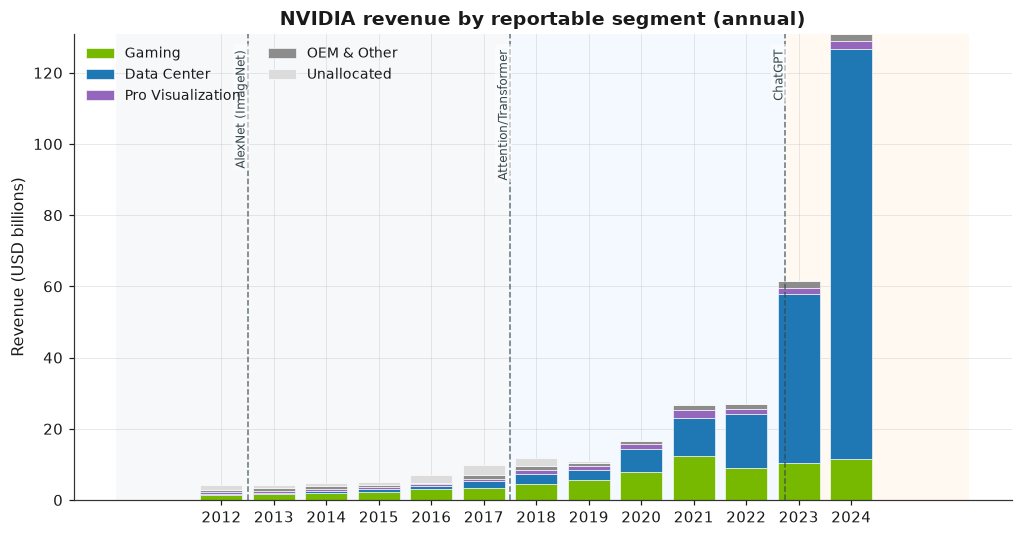

In [19]:
fig, ax = plt.subplots()
bands = list(common.SEGMENT_COLORS.keys())
years = seg["calendar_year"].astype(int).values
bottom = np.zeros(len(seg))
for b in bands:
    h = (seg[b]/1e3).values
    ax.bar(years, h, bottom=bottom, width=0.8, color=common.SEGMENT_COLORS[b],
           label=common.SEGMENT_LABELS[b], edgecolor="white", linewidth=0.4, zorder=2)
    bottom += h
common.add_era_bands_year(ax); common.add_milestones_year(ax)
ax.set_xticks(years); ax.set_xticklabels([str(y) for y in years], rotation=0)
ax.set_ylabel("Revenue (USD billions)")
ax.set_title("NVIDIA revenue by reportable segment (annual)")
ax.legend(loc="upper left", ncol=2)
save(fig, "03_nvda_segments"); plt.show()

Profitability shown as a **revenue decomposition** — each year's bar is 100% of revenue split into cost of revenue, operating expenses, other (tax/interest), and net income. The cumulative tops *are* the margins: top of **Net income** = net margin, **+Other** = operating margin, **+Operating expenses** = gross margin. (Stacking the three margins directly would be invalid — they're nested — so this is the correct way to see all three at once.)

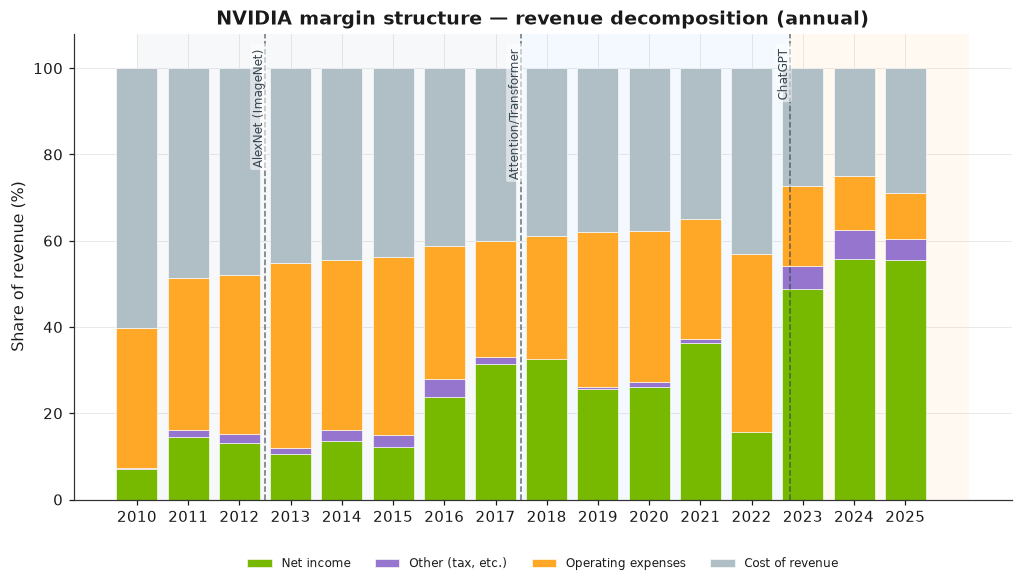

In [20]:
nvq = panel[panel.ticker == "NVDA"].copy()
nvq["year"] = nvq["calendar_quarter"].str[:4].astype(int)
cols = ["revenue", "gross_profit", "operating_income", "net_income"]
nvq = nvq.dropna(subset=cols)
full = nvq.groupby("year")["revenue"].size()
yrs = full[full == 4].index                      # complete fiscal years only
g = nvq[nvq.year.isin(yrs)].groupby("year")[cols].sum()
rev = g["revenue"]

layers = [
    ("Net income",         g["net_income"] / rev * 100,                            common.color("NVDA")),
    ("Other (tax, etc.)",  (g["operating_income"] - g["net_income"]) / rev * 100,  "#9575cd"),
    ("Operating expenses", (g["gross_profit"] - g["operating_income"]) / rev * 100, "#ffa726"),
    ("Cost of revenue",    (rev - g["gross_profit"]) / rev * 100,                  "#b0bec5"),
]
years = g.index.values
fig, ax = plt.subplots()
bottom = np.zeros(len(years))
for name, vals, col in layers:
    ax.bar(years, vals.values, bottom=bottom, width=0.8, color=col,
           label=name, edgecolor="white", linewidth=0.4, zorder=2)
    bottom += vals.values
common.add_era_bands_year(ax); common.add_milestones_year(ax, label=True)
ax.set_xticks(years); ax.set_xticklabels([str(y) for y in years], rotation=0)
ax.set_ylim(0, 108)
ax.set_ylabel("Share of revenue (%)")
ax.set_title("NVIDIA margin structure — revenue decomposition (annual)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=8, frameon=False)
save(fig, "04_nvda_margin_structure"); plt.show()

> **Finding (to write):** describe the slope changes, the Data-Center crossover, and the margin re-rating, and where each falls relative to the era boundaries.

## 2. Peer divergence (RQ1)

How NVIDIA separates from AMD, Intel, and the market benchmarks — in price, revenue, return correlation, margin, and revenue share — as the revenue model shifts toward data center. The last three are era-aggregated bars; the rest are time series.

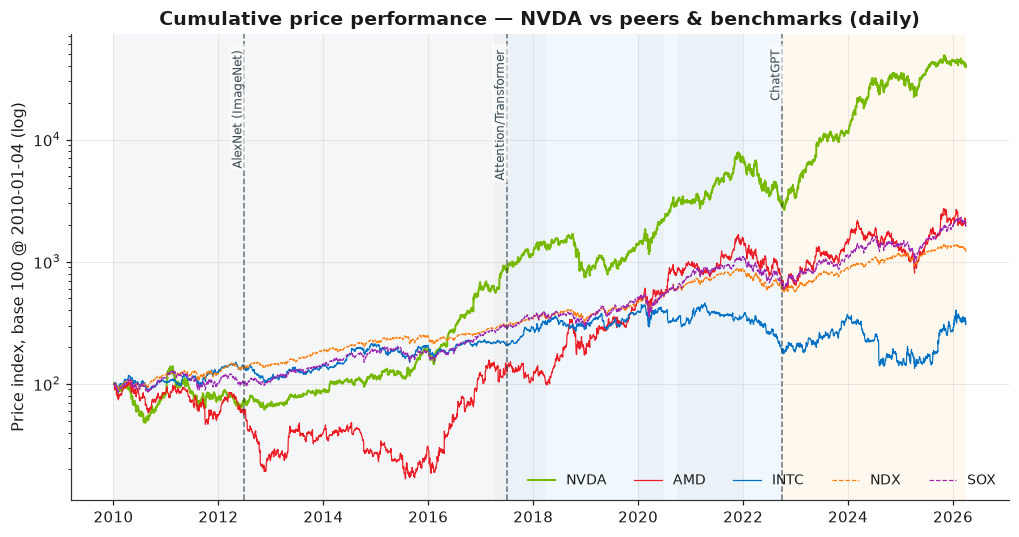

In [21]:
fig, ax = plt.subplots()
idx = common.daily_index(daily, ["NVDA", "AMD", "INTC", "NDX", "SOX"])
for tk in idx.columns:
    ax.plot(idx.index, idx[tk], color=common.color(tk),
            lw=1.3 if tk == "NVDA" else 0.8,
            ls="--" if tk in common.BENCHMARKS else "-", label=tk)
common.annotate(ax)
common.set_log(ax); common.style_time_axis(ax)
ax.set_ylabel("Price index, base 100 @ 2010-01-04 (log)")
ax.set_title("Cumulative price performance — NVDA vs peers & benchmarks (daily)")
ax.legend(ncol=5, loc="lower right")
save(fig, "05_peer_price_index"); plt.show()

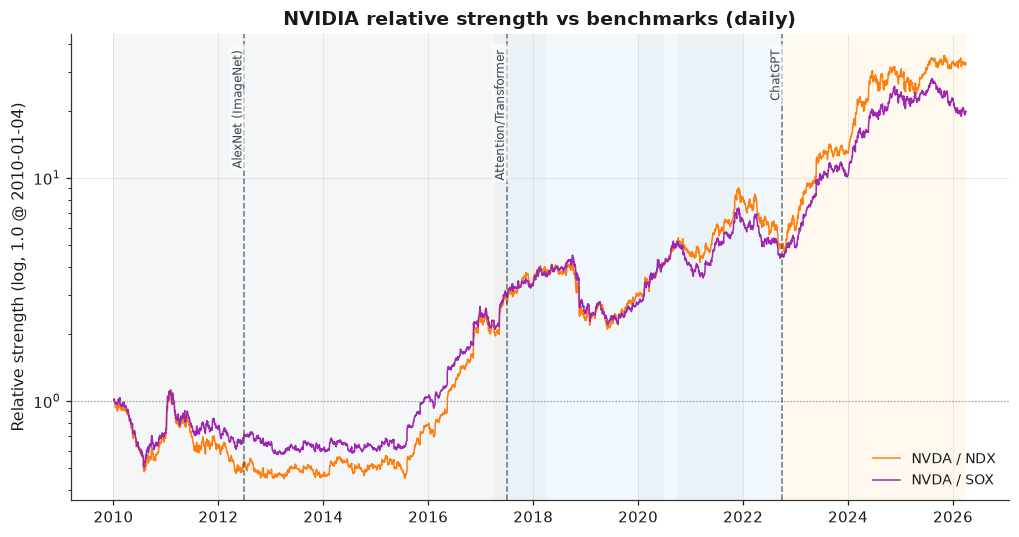

In [22]:
fig, ax = plt.subplots()
idx = common.daily_index(daily, ["NVDA", "NDX", "SOX"])
for bench in ["NDX", "SOX"]:
    ax.plot(idx.index, idx["NVDA"]/idx[bench], color=common.color(bench), lw=1.0, label=f"NVDA / {bench}")
ax.axhline(1, color="#999", lw=0.8, ls=":")
common.annotate(ax, milestone_labels=True)
common.set_log(ax); common.style_time_axis(ax)
ax.set_ylabel("Relative strength (log, 1.0 @ 2010-01-04)")
ax.set_title("NVIDIA relative strength vs benchmarks (daily)")
ax.legend(loc="lower right")
save(fig, "06_relative_strength"); plt.show()

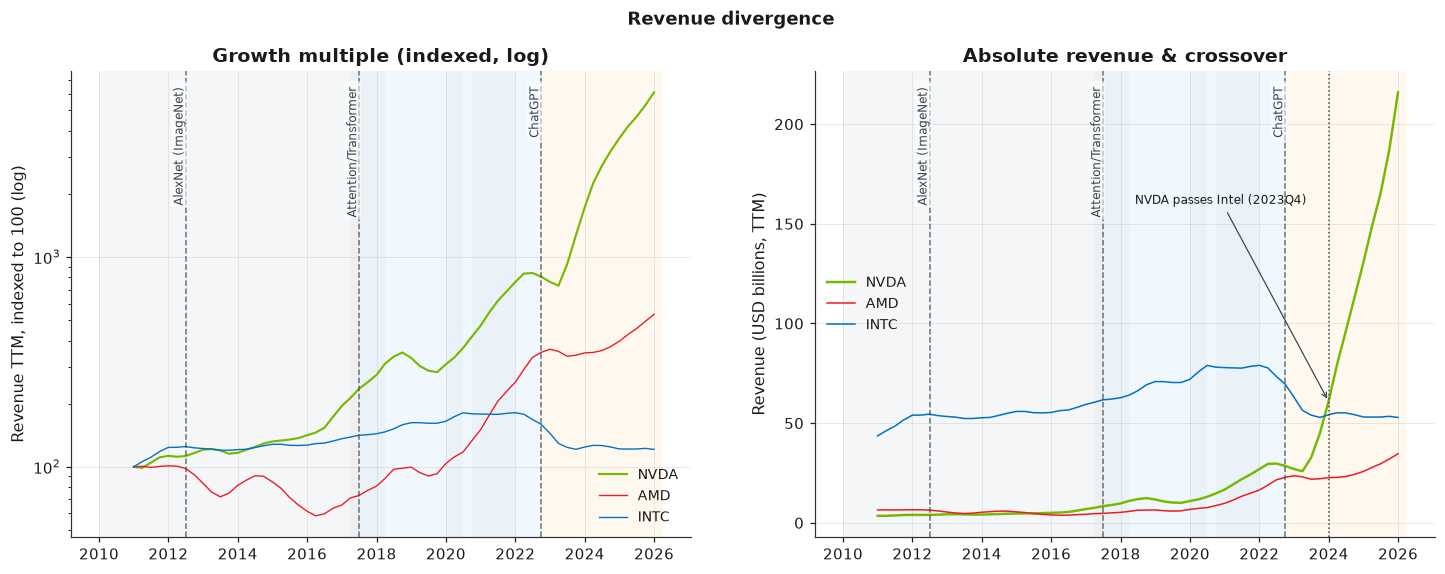

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# LEFT — current: indexed growth (log)
for tk in ["NVDA", "AMD", "INTC"]:
    s = common.ticker_series(panel, tk, "revenue_ttm")
    ax1.plot(s["date"], s["revenue_ttm"]/s["revenue_ttm"].iloc[0]*100,
             color=common.color(tk), lw=1.4 if tk == "NVDA" else 0.9, label=tk)
common.annotate(ax1); common.set_log(ax1); common.style_time_axis(ax1)
ax1.set_ylabel("Revenue TTM, indexed to 100 (log)")
ax1.set_title("Growth multiple (indexed, log)")
ax1.legend(loc="lower right")

# RIGHT — absolute $B & crossover (linear)
piv = panel.pivot_table(index="date", columns="ticker", values="revenue_ttm")
for tk in ["NVDA", "AMD", "INTC"]:
    s = common.ticker_series(panel, tk, "revenue_ttm")
    ax2.plot(s["date"], s["revenue_ttm"]/1e9, color=common.color(tk),
             lw=1.6 if tk == "NVDA" else 1.0, label=tk)
cx = piv[piv["NVDA"] > piv["INTC"]].index
if len(cx):
    d0 = cx.min()
    ax2.axvline(d0, color="#37474f", ls=":", lw=1)
    ax2.annotate(f"NVDA passes Intel ({d0.year}Q{(d0.month-1)//3+1})",
                 xy=(d0, piv.loc[d0, "NVDA"]/1e9),
                 xytext=(pd.Timestamp("2018-06-01"), 160), textcoords="data",
                 fontsize=8, ha="left",
                 arrowprops=dict(arrowstyle="->", color="#37474f", lw=0.8))
common.annotate(ax2, milestone_labels=True); common.style_time_axis(ax2)
ax2.set_ylabel("Revenue (USD billions, TTM)")
ax2.set_title("Absolute revenue & crossover")
ax2.legend(loc="center left")

fig.suptitle("Revenue divergence", fontweight="bold")
save(fig, "07_revenue_compare"); plt.show()

Return correlation, summarized to **one figure per era per pair** (daily log-returns *within* each era) instead of a rolling line. Each bar rests on ~1,000–1,800 trading days, so it's more stable than the 180-day rolling estimate, and the headline is unmistakable: NVIDIA's correlation with **Intel** falls sharply era over era while its tie to the **Nasdaq-100** stays high. The tradeoff vs. the rolling line is that within-era *timing* is no longer visible.

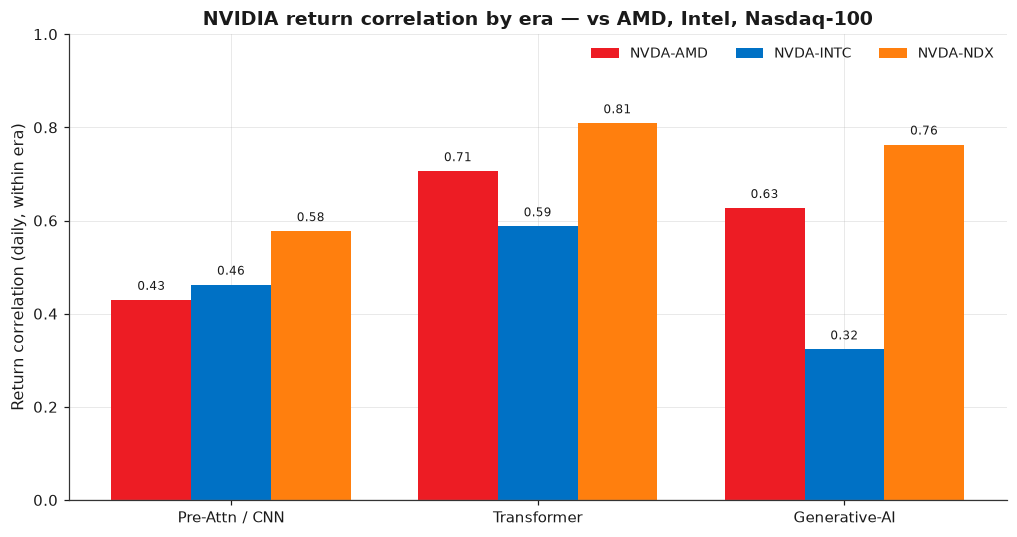

In [24]:
px = daily.pivot_table(index="date", columns="ticker", values="adj_close").sort_index()
rets = np.log(px).diff()
pairs = ["AMD", "INTC", "NDX"]
corr_era = {tk: [] for tk in pairs}
for era in common.ERAS:
    sub = rets.loc[(rets.index >= era.start) & (rets.index <= era.end)]
    for tk in pairs:
        corr_era[tk].append(sub["NVDA"].corr(sub[tk]))

x = np.arange(len(common.ERAS)); w = 0.26
fig, ax = plt.subplots()
for i, tk in enumerate(pairs):
    bars = ax.bar(x + (i - 1) * w, corr_era[tk], width=w, color=common.color(tk), label=f"NVDA-{tk}")
    for b, v in zip(bars, corr_era[tk]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}",
                ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="#999", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(["Pre-Attn / CNN", "Transformer", "Generative-AI"])
ax.set_ylabel("Return correlation (daily, within era)")
ax.set_title("NVIDIA return correlation by era — vs AMD, Intel, Nasdaq-100")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", ncol=3)
save(fig, "08_correlation_by_era"); plt.show()

Margin comparison across the three companies, aggregated to one figure per era (era total gross profit / era total revenue) so quarterly shocks don't clutter the picture. This is the visual twin of the synthesis era table.

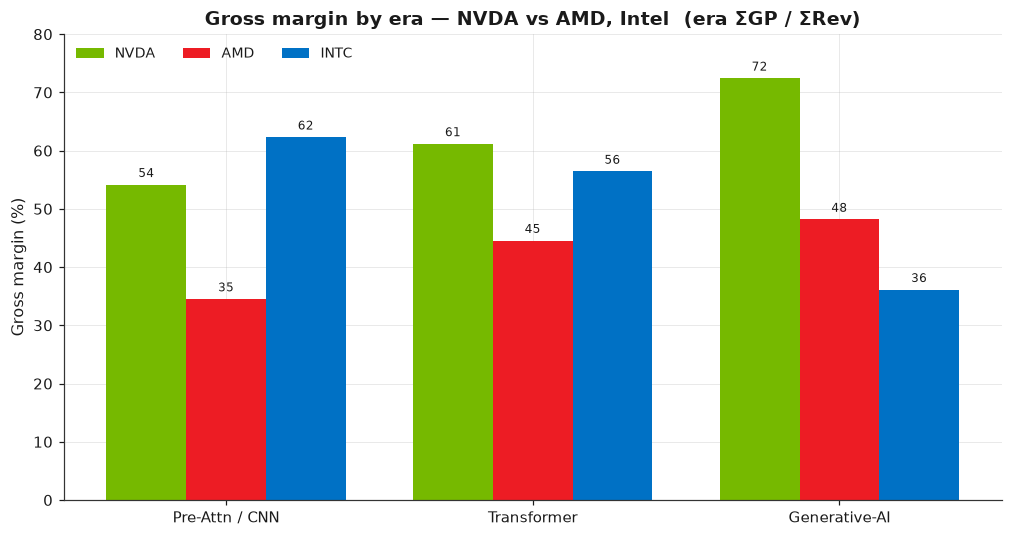

In [25]:
tickers = ["NVDA", "AMD", "INTC"]
eras = [e.name for e in common.ERAS]
gm_era = {tk: [panel[(panel.ticker == tk) & (panel.era == e)]["gross_profit"].sum()
               / panel[(panel.ticker == tk) & (panel.era == e)]["revenue"].sum() * 100
               for e in eras] for tk in tickers}

x = np.arange(len(eras)); w = 0.26
fig, ax = plt.subplots()
for i, tk in enumerate(tickers):
    bars = ax.bar(x + (i - 1) * w, gm_era[tk], width=w, color=common.color(tk), label=tk)
    for b, v in zip(bars, gm_era[tk]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.0f}",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["Pre-Attn / CNN", "Transformer", "Generative-AI"])
ax.set_ylabel("Gross margin (%)")
ax.set_title("Gross margin by era — NVDA vs AMD, Intel  (era ΣGP / ΣRev)")
ax.legend(loc="upper left", ncol=3)
ax.set_ylim(0, 80)
save(fig, "09_gross_margin_by_era"); plt.show()

Each firm's share of the **three companies' combined revenue**, by era (era-total revenue). Read this as relative size among the three, **not** product-market share — most of Intel's revenue is CPUs and NVIDIA's is GPUs, so it mixes different markets. Even so, the reversal is stark: Intel's share falls from ~84% to ~26% while NVIDIA's climbs from ~8% to ~61%.

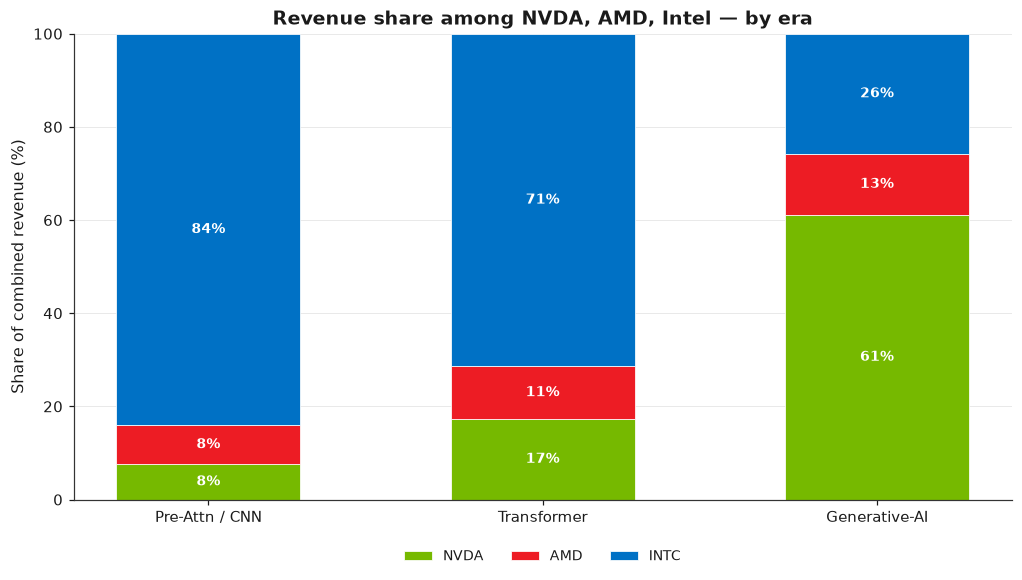

In [26]:
tickers = ["NVDA", "AMD", "INTC"]
eras = [e.name for e in common.ERAS]
share = {tk: [] for tk in tickers}
for e in eras:
    sub = panel[(panel.ticker.isin(tickers)) & (panel.era == e)]
    tot = {tk: sub[sub.ticker == tk]["revenue"].sum() for tk in tickers}
    s = sum(tot.values())
    for tk in tickers:
        share[tk].append(tot[tk] / s * 100)

x = np.arange(len(eras))
fig, ax = plt.subplots()
bottom = np.zeros(len(eras))
for tk in tickers:
    vals = np.array(share[tk])
    ax.bar(x, vals, bottom=bottom, width=0.55, color=common.color(tk),
           label=tk, edgecolor="white", linewidth=0.5)
    for xi, v, b0 in zip(x, vals, bottom):
        if v > 4:
            ax.text(xi, b0 + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottom += vals
ax.set_xticks(x); ax.set_xticklabels(["Pre-Attn / CNN", "Transformer", "Generative-AI"])
ax.set_ylim(0, 100)
ax.set_ylabel("Share of combined revenue (%)")
ax.set_title("Revenue share among NVDA, AMD, Intel — by era")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
save(fig, "10_revenue_share_by_era"); plt.show()

> **Finding (to write):** when does NVDA's price/revenue divergence open up, how do its return correlation and margin gap shift, and how does revenue share reverse across the eras?

## 3. Valuation (deferred)

Valuation ratios (P/E, P/S over time) need market capitalisation = *unadjusted* close x shares outstanding, which requires a small pipeline extension (raw close into the Yahoo step, shares outstanding into the SEC step). This section is intentionally left as a placeholder until that data is added.

## 4. Capex linkage

The demand backdrop: aggregate hyperscaler capital expenditure (Microsoft, Alphabet, Amazon, Meta) against NVIDIA's revenue. Formal lead/lag cross-correlation is left to the diagnostic notebook; here we show the co-movement.

Both series are in the **same unit** (USD billions), so they share **one scale** — the right axis only mirrors the left. This is deliberate: an independent dual axis can be rescaled to slide two lines into spurious alignment, which is a common way these charts mislead. A shared scale keeps the comparison honest. Read truthfully, hyperscaler capex sits *above* NVIDIA's revenue throughout, with NVIDIA closing from roughly 18% of the four firms' combined capex (through 2022) to about 57% by 2025 — capturing a fast-growing share, not matching it 1:1.

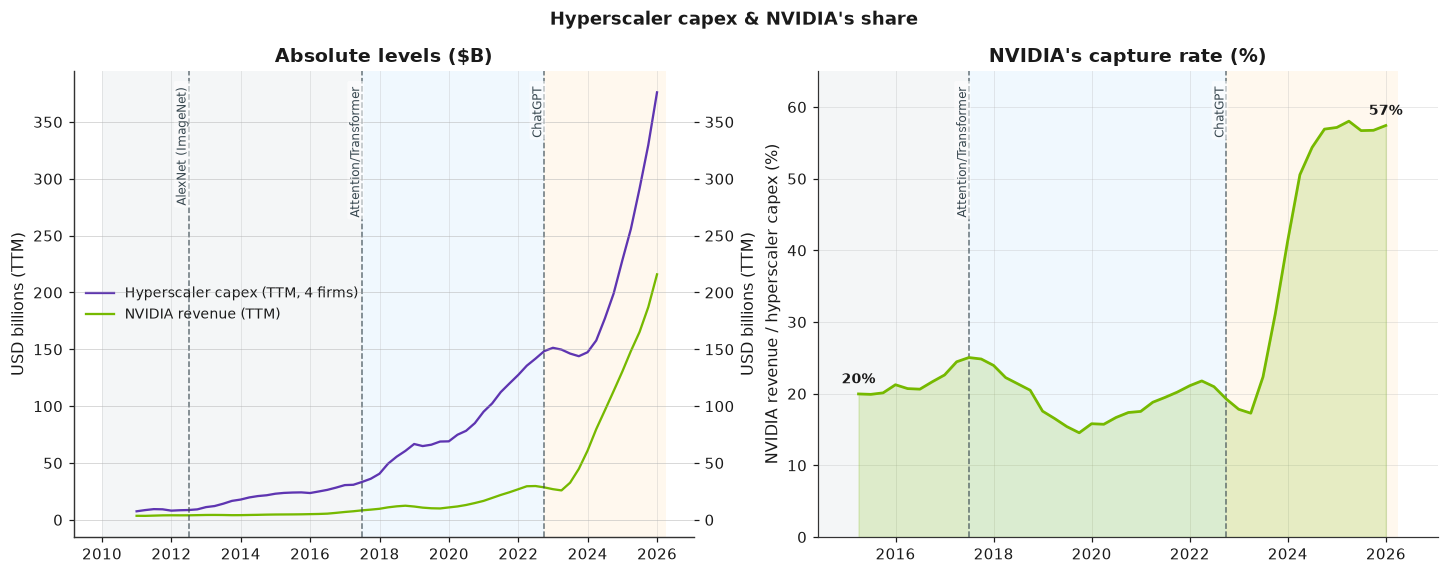

In [27]:
cap = panel[panel.ticker.isin(common.HYPERSCALERS)].pivot_table(
    index="date", columns="ticker", values="capex")
cap_ttm = cap.sum(axis=1, min_count=1).rolling(4).sum()
nr = common.ticker_series(panel, "NVDA", "revenue_ttm").set_index("date")["revenue_ttm"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# LEFT — current: shared-scale mirrored lines
ax1.plot(cap_ttm.index, cap_ttm/1e9, color="#5e35b1", lw=1.5, label="Hyperscaler capex (TTM, 4 firms)")
ax1.plot(nr.index, nr/1e9, color=common.color("NVDA"), lw=1.5, label="NVIDIA revenue (TTM)")
common.add_era_bands(ax1); common.add_milestones(ax1, label=True)
common.style_time_axis(ax1)
ax1.set_ylabel("USD billions (TTM)")
ax1b = ax1.twinx(); ax1b.set_ylim(ax1.get_ylim()); ax1b.set_ylabel("USD billions (TTM)")
ax1.set_title("Absolute levels ($B)")
ax1.legend(loc="center left")

# RIGHT — alternative: capture rate (from 2015)
rate = (nr/cap_ttm*100).dropna()
rate = rate[rate.index >= pd.Timestamp("2015-01-01")]
common.add_era_bands(ax2); common.add_milestones(ax2, label=True)
ax2.fill_between(rate.index, rate.values, color=common.color("NVDA"), alpha=0.18, zorder=1)
ax2.plot(rate.index, rate.values, color=common.color("NVDA"), lw=1.8, zorder=2)
for d in [rate.index[0], rate.index[-1]]:
    ax2.annotate(f"{rate.loc[d]:.0f}%", xy=(d, rate.loc[d]), xytext=(0, 7),
                 textcoords="offset points", ha="center", fontsize=9, fontweight="bold", color="#1a1a1a")
common.style_time_axis(ax2); ax2.set_ylim(0, 65); ax2.set_xlim(left=pd.Timestamp("2014-06-01"))
ax2.set_ylabel("NVIDIA revenue / hyperscaler capex (%)")
ax2.set_title("NVIDIA's capture rate (%)")

fig.suptitle("Hyperscaler capex & NVIDIA's share", fontweight="bold")
save(fig, "11_capex_compare"); plt.show()

> **Finding (to write):** how does NVIDIA's revenue track hyperscaler capex across the eras, and when does the gap begin to close?

## Synthesis — era comparison

A compact per-era summary for NVIDIA. This table and a written narrative belong in `findings/`.

In [28]:
rows = []
nv = panel[panel.ticker == "NVDA"]
for era in common.ERAS:
    e = nv[nv.era == era.name]
    rows.append({
        "Era": era.name,
        "Quarters": len(e),
        "Price idx (end)": round(e["price_index_100"].dropna().iloc[-1]) if e["price_index_100"].notna().any() else None,
        "Revenue TTM end ($B)": round(e["revenue_ttm"].dropna().iloc[-1]/1e9, 1) if e["revenue_ttm"].notna().any() else None,
        "Avg gross margin (%)": round(e["gross_margin"].mean()*100, 1),
        "Avg QoQ return (%)": round(e["qoq_return"].mean()*100, 1),
    })
era_table = pd.DataFrame(rows)
era_table

,Era,Quarters,Price idx (end),Revenue TTM end ($B),Avg gross margin (%),Avg QoQ return (%)
0,Pre-Attention / CNN,30,895,8.3,52.9,9.7
1,Transformer,21,3040,28.6,61.1,10.0
2,Generative-AI,14,43731,215.9,71.6,24.7


---
### Findings (to write)

Summarise the descriptive story here, era by era, in **non-causal** language — what shifted and when it lines up with the AI milestones, without asserting the milestones caused it. Move the polished write-up into `findings/` and the exported charts are already in `figures/`.